# PHÂN TÍCH TỔNG HỢP - HOTEL BOOKING DEMAND

Notebook này tích hợp kết quả từ:

- Bài 1: Khảo sát và tiền xử lý dữ liệu Hotel Booking Demand.
- Bài 2: Classification dự đoán `is_canceled`.
- Bài 4: Clustering hành vi booking bằng K-Means và DBSCAN.

Mục tiêu của notebook không phải là lặp lại toàn bộ các bài thực hành, mà là dùng các kết quả kỹ thuật đã có để phân tích tổng hợp: nhóm booking nào có tỷ lệ hủy cao/thấp, và kết quả đó liên hệ như thế nào với bài toán dự đoán hủy phòng.

## 01. Business Understanding

Hotel Booking Demand là bộ dữ liệu mô tả các đơn đặt phòng của khách sạn. Mỗi dòng dữ liệu tương ứng với một booking, bao gồm thông tin như loại khách sạn, thời gian đặt trước, thời điểm đến, số đêm lưu trú, số khách, phân khúc thị trường, loại đặt cọc, giá phòng trung bình và trạng thái hủy.

Trong nghiệp vụ khách sạn, booking bị hủy có thể ảnh hưởng trực tiếp đến kế hoạch phòng, doanh thu kỳ vọng và cách khách sạn quản lý rủi ro. Vì vậy, bài toán chính của đồ án là:

> Sử dụng dữ liệu booking để phân tích các đặc điểm liên quan đến khả năng hủy phòng và nhận diện các nhóm booking có hành vi khác nhau.

### Phạm vi kế thừa từ các bài đã làm

Notebook này kế thừa các quyết định chính từ Bài 1, Bài 2 và Bài 4:

- Bài 1 đã loại `reservation_status` và `reservation_status_date` vì đây là thông tin sau kết quả booking, có nguy cơ gây rò rỉ nhãn.
- Bài 1 xử lý missing values, outliers, tạo `total_stay`, `total_people`, `is_family`, One-Hot Encoding một số biến và xuất `hotel_bookings_processed.csv`.
- Bài 2 sử dụng Classification để dự đoán `is_canceled`, với sample 40,000 dòng cho D1.
- Bài 4 sử dụng Clustering để gom nhóm booking; DBSCAN cuối cùng chạy trên sample 15,000 dòng.

Lưu ý quan trọng: Classification và DBSCAN dùng hai sample khác nhau, nên notebook này không so sánh từng dòng dữ liệu giữa hai kỹ thuật nếu chưa có bước align sample/prediction rõ ràng.

## 02. Guiding Questions

### Guiding Question 1

**Những đặc điểm nào của booking có liên quan đến khả năng hủy, và có thể kết hợp Classification và Clustering để nhận diện sớm những booking có nguy cơ hủy cao hay không?**

Classification giúp đánh giá khả năng dự đoán `is_canceled`. Clustering giúp xem trong dữ liệu có những nhóm booking nào có đặc điểm tương tự nhau. Hai kỹ thuật được kết hợp ở mức phân tích tổng hợp, không so sánh trực tiếp từng dòng do sample khác nhau.

### Guiding Question 2

**Các nhóm booking được hình thành từ những đặc điểm nào, và các nhóm này có khác biệt về tỷ lệ hủy `is_canceled` hay không?**

Để trả lời câu hỏi này, `is_canceled` không được đưa vào đầu vào clustering. Sau khi có nhãn cluster, `is_canceled` mới được ghép lại để tính cancellation rate theo từng cluster.

### Mapping câu hỏi với kỹ thuật

| Guiding Question | Classification | Clustering | Cách sử dụng trong notebook |
|---|---:|---:|---|
| Q1 | Có | Có | Đọc metric Classification thật từ `D1_metrics.csv`; đối chiếu ở mức insight với cancellation rate theo cluster |
| Q2 | Không trực tiếp | Có | Dùng DBSCAN để tạo cluster, sau đó phân tích `is_canceled` theo cluster |
| Cross-technique | Có | Có | Không so sánh row-level giữa sample 40,000 và sample 15,000 nếu chưa align |

## 03. Analysis Dataset & Scope

Phần này đọc dữ liệu đã xử lý từ Bài 1. Nếu notebook được đặt trong project `data-mining`, đường dẫn kỳ vọng là:

```text
data/processed/D1_hotel_booking/hotel_bookings_processed.csv
```

Dữ liệu sau Bài 1 có 117,398 dòng và 43 cột theo kết quả notebook đã chạy trước đó.

In [3]:
from pathlib import Path
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_theme(style="whitegrid", palette="muted")

RANDOM_STATE = 42
CLASSIFICATION_SAMPLE_N = 40000
DBSCAN_SAMPLE_N = 15000
DBSCAN_EPS = 9.0

In [5]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]

    for base in candidates:
        processed = base / "data" / "processed" / "D1_hotel_booking" / "hotel_bookings_processed.csv"
        raw = base / "data" / "raw"

        if processed.exists() or raw.exists():
            return base

        nested = base / "DataMining" / "DO_AN"
        processed_nested = nested / "data" / "processed" / "D1_hotel_booking" / "hotel_bookings_processed.csv"
        if processed_nested.exists():
            return nested

    return start


PROJECT = find_project_root()
DATA_PATH = PROJECT /  "data" / "hotel_bookings_processed.csv"
CLASSIFICATION_OUT = PROJECT / "output"

print("Project root:", PROJECT)
print("Processed data path:", DATA_PATH)
print("Classification output path:", CLASSIFICATION_OUT)

Project root: e:\CODECNTT\DU_AN\DataMining\DO_AN
Processed data path: e:\CODECNTT\DU_AN\DataMining\DO_AN\data\hotel_bookings_processed.csv
Classification output path: e:\CODECNTT\DU_AN\DataMining\DO_AN\output


In [6]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Không tìm thấy hotel_bookings_processed.csv. "
        "Hãy chạy Bài 1 trước hoặc chỉnh DATA_PATH tới file đã xử lý."
    )

df_raw = pd.read_csv(DATA_PATH)

print("Kích thước dữ liệu sau Bài 1:", df_raw.shape)
display(df_raw.head())

Kích thước dữ liệu sau Bài 1: (117398, 43)


,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,meal_Undefined,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,deposit_type_Non Refund,deposit_type_Refundable
0,0,-0.917518,2015,July,27,1,0,1,1,0.0,...,False,False,False,True,False,False,False,False,False,False
1,0,-0.861398,2015,July,27,1,0,1,1,0.0,...,False,False,True,False,False,False,False,False,False,False
2,0,-0.852045,2015,July,27,1,0,2,2,0.0,...,False,False,False,False,False,False,True,False,False,False
3,0,-0.852045,2015,July,27,1,0,2,2,0.0,...,False,False,False,False,False,False,True,False,False,False
4,0,-0.982992,2015,July,27,1,0,2,2,0.0,...,False,False,False,True,False,False,False,False,False,False


In [7]:
dataset_scope = pd.DataFrame({
    "Hạng mục": [
        "Dataset gốc",
        "Dữ liệu sau Bài 1",
        "Target phân tích",
        "Classification Bài 2",
        "DBSCAN Bài 4",
        "Ràng buộc quan trọng"
    ],
    "Mô tả": [
        "Hotel Booking Demand, 119,390 dòng x 32 thuộc tính gốc",
        f"{df_raw.shape[0]:,} dòng x {df_raw.shape[1]:,} cột sau xử lý",
        "is_canceled: 0 = không hủy, 1 = hủy",
        f"Dùng sample {CLASSIFICATION_SAMPLE_N:,} dòng",
        f"Dùng sample {DBSCAN_SAMPLE_N:,} dòng",
        "Không so sánh row-level giữa Classification và DBSCAN nếu chưa align sample"
    ]
})

display(dataset_scope)

,Hạng mục,Mô tả
0,Dataset gốc,"Hotel Booking Demand, 119,390 dòng x 32 thuộc ..."
1,Dữ liệu sau Bài 1,"117,398 dòng x 43 cột sau xử lý"
2,Target phân tích,"is_canceled: 0 = không hủy, 1 = hủy"
3,Classification Bài 2,"Dùng sample 40,000 dòng"
4,DBSCAN Bài 4,"Dùng sample 15,000 dòng"
5,Ràng buộc quan trọng,Không so sánh row-level giữa Classification và...


,is_canceled,meaning,percent
0,0,Không hủy,62.51
1,1,Hủy,37.49


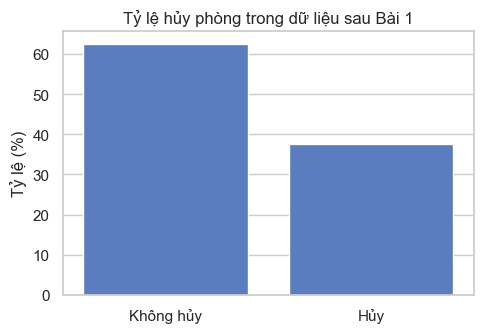

In [8]:
target_summary = (
    df_raw["is_canceled"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)
target_summary.columns = ["is_canceled", "percent"]
target_summary["meaning"] = target_summary["is_canceled"].map({0: "Không hủy", 1: "Hủy"})
target_summary["percent"] = target_summary["percent"].round(2)

display(target_summary[["is_canceled", "meaning", "percent"]])

plt.figure(figsize=(5, 3.5))
sns.barplot(data=target_summary, x="meaning", y="percent")
plt.title("Tỷ lệ hủy phòng trong dữ liệu sau Bài 1")
plt.xlabel("")
plt.ylabel("Tỷ lệ (%)")
plt.tight_layout()
plt.show()

## 04. Technical Results Reuse

Phần này không chạy lại toàn bộ Bài 2 và Bài 4. Notebook chỉ kế thừa những kết quả kỹ thuật cần thiết:

- Classification: đọc metric thật từ `D1_metrics.csv` nếu file đã tồn tại.
- Clustering: ghi nhận kết quả Bài 4 và chạy lại DBSCAN cuối cùng trên sample 15,000 để phân tích `is_canceled` theo cluster.

Không tự bịa metric Classification. Nếu chưa có `D1_metrics.csv`, cần chạy lại Bài 2 hoặc điền đúng đường dẫn file metric.

In [9]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

# Thêm trực tiếp đường dẫn Path('../data/D1_metrics.csv') vào đầu danh sách
metrics_candidates = [
    Path('../data/D1_metrics.csv'),
    Path('data/D1_metrics.csv'),
    Path('../output/D1_metrics.csv'),
]

metrics_path = next((p for p in metrics_candidates if p.exists()), None)

if metrics_path is None:
    d1_metrics = pd.DataFrame(columns=["dataset", "model", "accuracy", "precision", "recall", "f1", "roc_auc"])
    display(Markdown(
        "**Chưa tìm thấy `D1_metrics.csv`.** "
        "Không điền số liệu Classification ở notebook này. "
        "Hãy chạy lại Bài 2 hoặc đặt file metric vào `bai2-phan-lop/outputs/D1_metrics.csv`."
    ))
else:
    d1_metrics = pd.read_csv(metrics_path)
    print("Đã đọc Classification metrics từ:", metrics_path)
    display(d1_metrics)

Đã đọc Classification metrics từ: data\D1_metrics.csv


,dataset,model,accuracy,precision,recall,f1,roc_auc
0,D1,Decision Tree,0.788375,0.578752,0.850658,0.688844,0.890328
1,D1,Logistic Regression,0.748125,0.528852,0.782115,0.631020,0.841971


In [10]:
if not d1_metrics.empty:
    metric_cols = [c for c in ["accuracy", "precision", "recall", "f1", "roc_auc"] if c in d1_metrics.columns]
    display(
        d1_metrics
        .sort_values("f1", ascending=False)
        [["model", *metric_cols]]
        .reset_index(drop=True)
    )

    best_cls = d1_metrics.sort_values("f1", ascending=False).iloc[0]
    display(Markdown(
        f"**Mô hình Classification tốt nhất theo F1 trong file metric hiện có:** "
        f"`{best_cls['model']}`. "
        "Kết luận này chỉ dựa trên `D1_metrics.csv`"
    ))
else:
    display(Markdown(
        "Chưa có metric thật của Classification, vì vậy phần synthesis bên dưới chỉ nhắc vai trò của Classification, "
        "không kết luận mô hình nào tốt hơn."
    ))

,model,accuracy,precision,recall,f1,roc_auc
0,Decision Tree,0.788375,0.578752,0.850658,0.688844,0.890328
1,Logistic Regression,0.748125,0.528852,0.782115,0.631020,0.841971


**Mô hình Classification tốt nhất theo F1 trong file metric hiện có:** `Decision Tree`. Kết luận này chỉ dựa trên `D1_metrics.csv`

In [11]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

# Trỏ trực tiếp vào thư mục data cùng cấp
params_path = Path('data/D1_best_params.json')

if params_path.exists():
    with open(params_path, "r", encoding="utf-8") as f:
        d1_params = json.load(f)

    display(pd.DataFrame([
        {"model": model, "best_params": params}
        for model, params in d1_params.items()
    ]))
else:
    display(Markdown("Không tìm thấy `D1_best_params.json`; bỏ qua phần best parameters."))

,model,best_params
0,Logistic Regression,{'clf__C': 0.5}
1,Decision Tree,"{'clf__max_depth': 14, 'clf__min_samples_leaf'..."


In [12]:
clustering_reuse = pd.DataFrame({
    "Thuật toán": ["K-Means", "DBSCAN"],
    "Cấu hình kế thừa từ Bài 4": ["K = 2", "eps = 9.0, min_samples = 88"],
    "Sample dùng để đánh giá/chạy cuối": [
        "K-Means fit trên toàn bộ dữ liệu; Silhouette tính trên sample 15,000",
        "DBSCAN chạy trên sample 15,000"
    ],
    "Số cụm": [2, 3],
    "Silhouette": [0.2226, 0.4146],
    "Davies-Bouldin": [2.5680, 0.9486],
    "Noise (%)": [0.00, 1.72]
})

display(clustering_reuse)

,Thuật toán,Cấu hình kế thừa từ Bài 4,Sample dùng để đánh giá/chạy cuối,Số cụm,Silhouette,Davies-Bouldin,Noise (%)
0,K-Means,K = 2,K-Means fit trên toàn bộ dữ liệu; Silhouette t...,2,0.2226,2.5680,0.00
1,DBSCAN,"eps = 9.0, min_samples = 88","DBSCAN chạy trên sample 15,000",3,0.4146,0.9486,1.72


Biểu đồ so sánh mô hình Classification

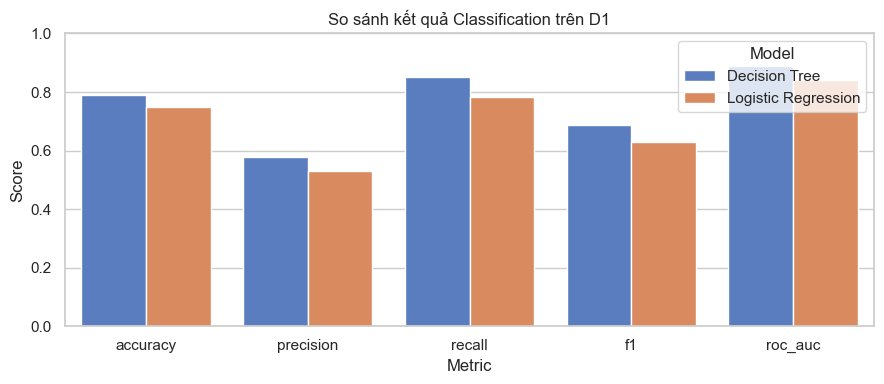

In [35]:
metric_plot = d1_metrics.melt(
    id_vars=["model"],
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(9, 4))
sns.barplot(data=metric_plot, x="metric", y="score", hue="model")
plt.title("So sánh kết quả Classification trên D1")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### Nhận xét kỹ thuật kế thừa

Trong Bài 4, DBSCAN có Silhouette cao hơn và Davies-Bouldin thấp hơn K-Means, đồng thời có khả năng tách một phần điểm nhiễu. Vì vậy, phần phân tích chéo bên dưới dùng DBSCAN làm cấu hình clustering chính.

Tuy nhiên, DBSCAN ở đây chỉ được chạy trên sample 15,000 dòng. Do đó các kết luận về cluster cần được hiểu là phân tích trên sample này, không phải kết luận tuyệt đối cho toàn bộ 117,398 dòng.


## 05. Cross-Technique Analysis

Quy trình:

1. Tái tạo ma trận đặc trưng clustering giống Bài 4.
2. Không đưa `is_canceled` vào đầu vào clustering.
3. Chạy DBSCAN với `eps = 9.0`, `min_samples = 88` trên sample 15,000.
4. Ghép lại `is_canceled` sau khi đã có nhãn cluster.
5. Tính cancellation rate, profiling và diễn giải cụm.

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = globals().get("RANDOM_STATE", 42)
DBSCAN_SAMPLE_N = globals().get("DBSCAN_SAMPLE_N", 15000)
DBSCAN_EPS = globals().get("DBSCAN_EPS", 9.0)


def find_processed_data(start=None):
    start = Path.cwd() if start is None else Path(start)

    relative_candidates = [
        Path("data/hotel_bookings_processed.csv"),
        Path("data/processed/D1_hotel_booking/hotel_bookings_processed.csv"),
        Path("../data/hotel_bookings_processed.csv"),
        Path("../data/processed/D1_hotel_booking/hotel_bookings_processed.csv"),
        Path("../data-mining/data/processed/D1_hotel_booking/hotel_bookings_processed.csv"),
        Path("../../data/processed/D1_hotel_booking/hotel_bookings_processed.csv"),
    ]

    for rel_path in relative_candidates:
        candidate = start / rel_path
        if candidate.exists():
            return candidate

    for base in [start, *start.parents]:
        candidates = [
            base / "data" / "hotel_bookings_processed.csv",
            base / "data" / "processed" / "D1_hotel_booking" / "hotel_bookings_processed.csv",
        ]
        for candidate in candidates:
            if candidate.exists():
                return candidate

    return None


if "df_raw" not in globals():
    DATA_PATH = find_processed_data()

    if DATA_PATH is None:
        raise FileNotFoundError(
            "Không tìm thấy hotel_bookings_processed.csv bằng đường dẫn tương đối. "
            "Hãy đặt file vào thư mục data/ hoặc data/processed/D1_hotel_booking/ cạnh notebook."
        )

    df_raw = pd.read_csv(DATA_PATH)
    print("Đã đọc lại df_raw từ:", DATA_PATH)
else:
    print("Đã có sẵn df_raw trong bộ nhớ.")

print("Kích thước df_raw:", df_raw.shape)

if "is_canceled" not in df_raw.columns:
    raise ValueError("Thiếu cột is_canceled trong df_raw.")

DROP_COLS = [
    "is_canceled",
    "country",
    "agent",
    "company",
    "reserved_room_type",
    "assigned_room_type",
]

df_cluster_base = df_raw.drop(
    columns=[c for c in DROP_COLS if c in df_raw.columns]
).copy()

month_map = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}

df_enc = df_cluster_base.copy()

if "arrival_date_month" in df_enc.columns:
    df_enc["arrival_date_month"] = df_enc["arrival_date_month"].map(month_map)

cat_to_encode = [
    c for c in ["distribution_channel", "customer_type"]
    if c in df_enc.columns
]
df_enc = pd.get_dummies(df_enc, columns=cat_to_encode, dtype=int)

object_cols = df_enc.select_dtypes(include="object").columns.tolist()
if object_cols:
    raise ValueError(f"Còn cột dạng object chưa encode: {object_cols}")

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_enc),
    columns=df_enc.columns,
    index=df_enc.index
)

X = df_scaled.values

print("df_cluster_base:", df_cluster_base.shape)
print("df_enc:", df_enc.shape)
print("X:", X.shape)


Đã có sẵn df_raw trong bộ nhớ.
Kích thước df_raw: (117398, 43)
df_cluster_base: (117398, 37)
df_enc: (117398, 44)
X: (117398, 44)


Bước 5.2 - Tạo sample DBSCAN

In [15]:
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(X.shape[0], size=DBSCAN_SAMPLE_N, replace=False)
X_sample = X[sample_idx]

min_samples = 2 * X.shape[1]

print("Số đặc trưng D:", X.shape[1])
print("min_samples:", min_samples)
print("DBSCAN sample:", X_sample.shape)

Số đặc trưng D: 44
min_samples: 88
DBSCAN sample: (15000, 44)


In [16]:
from sklearn.cluster import DBSCAN

dbscan_final = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=min_samples,
    metric="euclidean",
    n_jobs=-1
)

sample_labels = dbscan_final.fit_predict(X_sample)

n_clusters = len(set(sample_labels)) - (1 if -1 in sample_labels else 0)
n_noise = int(np.sum(sample_labels == -1))
noise_rate = n_noise / len(sample_labels) * 100

print(f"DBSCAN final: eps={DBSCAN_EPS}, min_samples={min_samples}")
print(f"Số cụm, không tính noise: {n_clusters}")
print(f"Số điểm noise: {n_noise} ({noise_rate:.2f}%)")


DBSCAN final: eps=9.0, min_samples=88
Số cụm, không tính noise: 3
Số điểm noise: 258 (1.72%)


Biểu đồ PCA 2D minh họa cluster DBSCAN

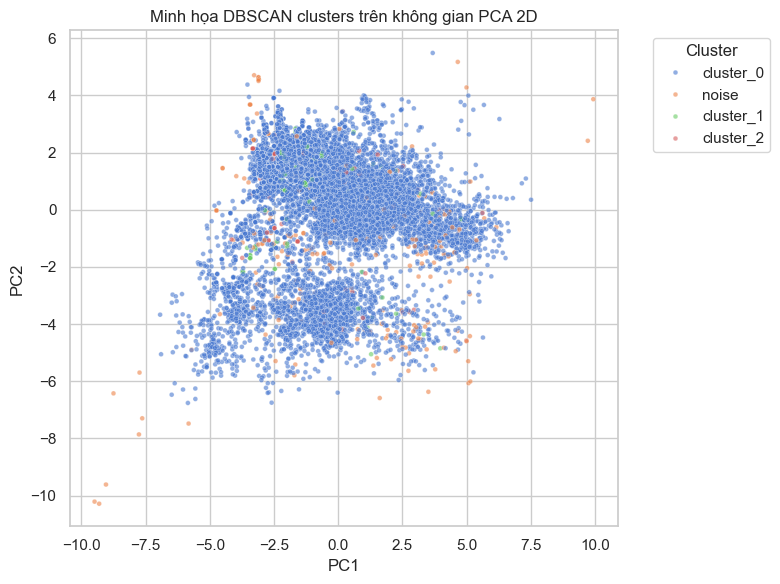

In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_sample)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": sample_labels
})

pca_df["cluster_label"] = pca_df["cluster"].map(
    lambda x: "noise" if x == -1 else f"cluster_{x}"
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster_label",
    s=12,
    alpha=0.6
)
plt.title("Minh họa DBSCAN clusters trên không gian PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Biểu đồ PCA 2D chỉ dùng để minh họa trực quan các cluster trong không gian giảm chiều. DBSCAN vẫn được chạy trên toàn bộ 44 đặc trưng đã chuẩn hóa, không phải trên hai thành phần PCA này. Vì vậy, biểu đồ này chỉ hỗ trợ quan sát, không dùng làm bằng chứng chính để đánh giá chất lượng clustering.

Bước 5.4 - Đánh giá DBSCAN

In [17]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

mask = sample_labels != -1

if len(np.unique(sample_labels[mask])) >= 2:
    sil = silhouette_score(X_sample[mask], sample_labels[mask])
    dbi = davies_bouldin_score(X_sample[mask], sample_labels[mask])
else:
    sil = np.nan
    dbi = np.nan

dbscan_check = pd.DataFrame([{
    "eps": DBSCAN_EPS,
    "min_samples": min_samples,
    "sample_n": len(sample_labels),
    "n_clusters_without_noise": n_clusters,
    "n_noise": n_noise,
    "noise_rate_percent": round(noise_rate, 2),
    "silhouette_without_noise": round(sil, 4) if pd.notna(sil) else np.nan,
    "davies_bouldin_without_noise": round(dbi, 4) if pd.notna(dbi) else np.nan,
}])

display(dbscan_check)


,eps,min_samples,sample_n,n_clusters_without_noise,n_noise,noise_rate_percent,silhouette_without_noise,davies_bouldin_without_noise
0,9.0,88,15000,3,258,1.72,0.4146,0.9486


Cell Bước 5.5 - Ghép cluster với is_canceled

In [18]:
df_analysis = df_raw.iloc[sample_idx].copy()
df_analysis["cluster"] = sample_labels
df_analysis["cluster_label"] = df_analysis["cluster"].map(
    lambda x: "noise" if x == -1 else f"cluster_{x}"
)

print(df_analysis.shape)
display(df_analysis[["cluster", "cluster_label", "is_canceled"]].head())


(15000, 45)


,cluster,cluster_label,is_canceled
104476,0,cluster_0,0
103143,0,cluster_0,0
95596,0,cluster_0,0
46590,0,cluster_0,1
1199,0,cluster_0,1


Bước 5.6 - Kích thước cluster

In [19]:
cluster_size = (
    df_analysis["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)

cluster_size["percentage"] = (cluster_size["count"] / len(df_analysis) * 100).round(2)
cluster_size["cluster_label"] = cluster_size["cluster"].map(
    lambda x: "noise" if x == -1 else f"cluster_{x}"
)

display(cluster_size[["cluster", "cluster_label", "count", "percentage"]])


,cluster,cluster_label,count,percentage
0,-1,noise,258,1.72
1,0,cluster_0,14509,96.73
2,1,cluster_1,134,0.89
3,2,cluster_2,99,0.66


Biểu đồ kích thước cluster

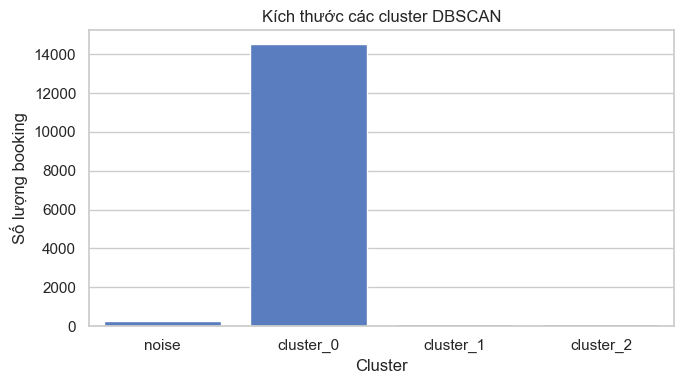

In [37]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=cluster_size,
    x="cluster_label",
    y="count"
)
plt.title("Kích thước các cluster DBSCAN")
plt.xlabel("Cluster")
plt.ylabel("Số lượng booking")
plt.tight_layout()
plt.show()

Bước 5.7 - cancellation rate theo cluster

In [20]:
overall_cancel_rate = df_analysis["is_canceled"].mean()

cluster_cancel = (
    df_analysis
    .groupby("cluster")
    .agg(
        n=("is_canceled", "size"),
        cancellations=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

cluster_cancel["cluster_label"] = cluster_cancel["cluster"].map(
    lambda x: "noise" if x == -1 else f"cluster_{x}"
)
cluster_cancel["share_percent"] = (cluster_cancel["n"] / len(df_analysis) * 100).round(2)
cluster_cancel["cancellation_rate_percent"] = (cluster_cancel["cancellation_rate"] * 100).round(2)
cluster_cancel["lift_vs_sample"] = (cluster_cancel["cancellation_rate"] / overall_cancel_rate).round(2)

display(Markdown(f"**Cancellation rate trung bình của sample DBSCAN:** {overall_cancel_rate * 100:.2f}%"))

display(cluster_cancel[[
    "cluster", "cluster_label", "n", "share_percent",
    "cancellations", "cancellation_rate_percent", "lift_vs_sample"
]].sort_values("cancellation_rate_percent", ascending=False))


**Cancellation rate trung bình của sample DBSCAN:** 37.79%

,cluster,cluster_label,n,share_percent,cancellations,cancellation_rate_percent,lift_vs_sample
3,2,cluster_2,99,0.66,52,52.53,1.39
1,0,cluster_0,14509,96.73,5524,38.07,1.01
2,1,cluster_1,134,0.89,37,27.61,0.73
0,-1,noise,258,1.72,56,21.71,0.57


Bước 5.8 - Biểu đồ cancellation rate

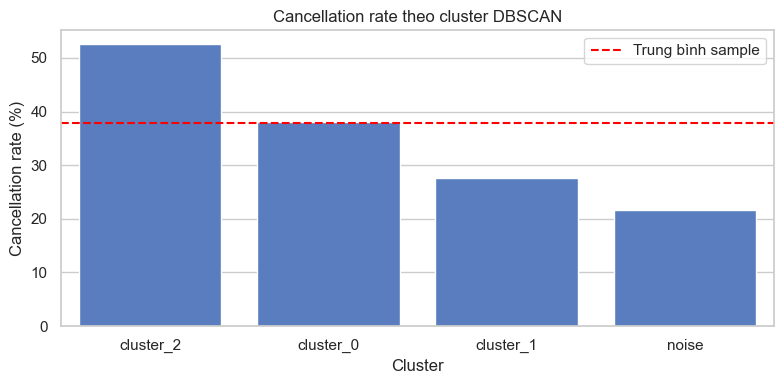

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = cluster_cancel.sort_values("cancellation_rate_percent", ascending=False).copy()

plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x="cluster_label", y="cancellation_rate_percent")
plt.axhline(overall_cancel_rate * 100, color="red", linestyle="--", label="Trung bình sample")
plt.title("Cancellation rate theo cluster DBSCAN")
plt.xlabel("Cluster")
plt.ylabel("Cancellation rate (%)")
plt.legend()
plt.tight_layout()
plt.show()


Bước 5.9 - profiling biến số

In [22]:
profile_cols = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "total_stay",
    "total_people",
    "total_of_special_requests",
]

profile_cols = [c for c in profile_cols if c in df_analysis.columns]

numeric_profile = (
    df_analysis[df_analysis["cluster"] != -1]
    .groupby("cluster")[profile_cols]
    .mean()
    .round(3)
)

display(numeric_profile)


,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,booking_changes,days_in_waiting_list,adr,total_stay,total_people,total_of_special_requests
cluster,,,,,,,,,,,,
0,-0.005,0.936,2.508,1.861,0.103,0.0,0.206,2.096,-0.005,-0.005,1.964,0.567
1,-0.005,1.149,3.172,1.910,0.090,0.0,0.291,8.746,-0.028,0.342,2.000,0.201
2,0.067,1.323,2.980,1.889,0.101,0.0,0.273,0.000,0.172,0.335,1.990,0.273


Bước 5.10 - chênh lệch so với trung bình sample

In [23]:
overall_profile = df_analysis[profile_cols].mean()

profile_diff = (
    df_analysis[df_analysis["cluster"] != -1]
    .groupby("cluster")[profile_cols]
    .mean()
    .subtract(overall_profile, axis=1)
    .round(3)
)

display(Markdown("**Chênh lệch trung bình của từng cluster so với toàn sample DBSCAN**"))
display(profile_diff)


**Chênh lệch trung bình của từng cluster so với toàn sample DBSCAN**

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,booking_changes,days_in_waiting_list,adr,total_stay,total_people,total_of_special_requests
cluster,,,,,,,,,,,,
0,0.001,-0.009,-0.019,-0.000,-0.001,-0.007,-0.010,-0.298,0.002,-0.011,-0.008,-0.000
1,0.001,0.205,0.645,0.049,-0.015,-0.007,0.074,6.352,-0.021,0.336,0.028,-0.365
2,0.074,0.379,0.453,0.028,-0.003,-0.007,0.056,-2.394,0.179,0.329,0.017,-0.294


Bước 5.11 - heatmap profiling

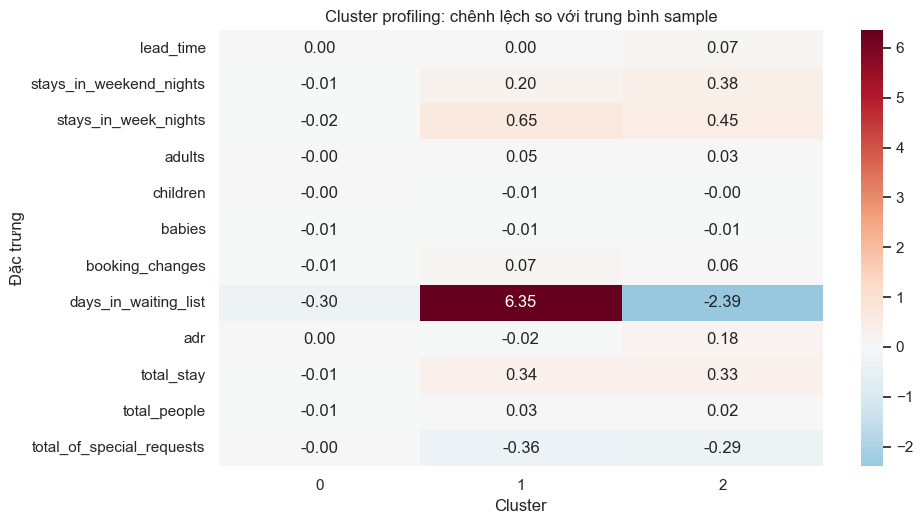

In [24]:
plt.figure(figsize=(10, max(3, 0.45 * len(profile_diff.columns))))
sns.heatmap(profile_diff.T, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Cluster profiling: chênh lệch so với trung bình sample")
plt.xlabel("Cluster")
plt.ylabel("Đặc trưng")
plt.tight_layout()
plt.show()


Bước 5.12 - profiling biến One-Hot

In [25]:
ohe_profile_cols = [
    c for c in df_analysis.columns
    if c.startswith(("hotel_", "meal_", "market_segment_", "deposit_type_"))
]

if ohe_profile_cols:
    ohe_profile = (
        df_analysis[df_analysis["cluster"] != -1]
        .groupby("cluster")[ohe_profile_cols]
        .mean()
        .round(3)
    )

    display(Markdown("**Tỷ lệ trung bình của các biến One-Hot trong từng cluster**"))
    display(ohe_profile)
else:
    display(Markdown("Không có cột One-Hot phù hợp để profiling."))


**Tỷ lệ trung bình của các biến One-Hot trong từng cluster**

,hotel_Resort Hotel,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,deposit_type_Non Refund,deposit_type_Refundable
cluster,,,,,,,,,,,,,,
0,0.325,0.0,0.125,0.091,0.0,0.0,0.043,0.106,0.157,0.202,0.489,0.0,0.123,0.0
1,1.000,0.0,0.000,0.000,1.0,0.0,0.030,0.067,0.701,0.187,0.015,0.0,0.194,0.0
2,0.949,1.0,0.000,0.000,0.0,0.0,0.020,0.111,0.545,0.263,0.061,0.0,0.303,0.0


Bước 5.13 - cluster rủi ro cao/thấp

In [26]:
high_risk_clusters = cluster_cancel[
    (cluster_cancel["cluster"] != -1) &
    (cluster_cancel["cancellation_rate"] > overall_cancel_rate)
].sort_values("cancellation_rate", ascending=False)

low_risk_clusters = cluster_cancel[
    (cluster_cancel["cluster"] != -1) &
    (cluster_cancel["cancellation_rate"] <= overall_cancel_rate)
].sort_values("cancellation_rate", ascending=True)

display(Markdown("### Cluster có cancellation rate cao hơn trung bình sample"))
display(high_risk_clusters[[
    "cluster_label", "n", "share_percent",
    "cancellation_rate_percent", "lift_vs_sample"
]])

display(Markdown("### Cluster có cancellation rate thấp hơn hoặc bằng trung bình sample"))
display(low_risk_clusters[[
    "cluster_label", "n", "share_percent",
    "cancellation_rate_percent", "lift_vs_sample"
]])


### Cluster có cancellation rate cao hơn trung bình sample

,cluster_label,n,share_percent,cancellation_rate_percent,lift_vs_sample
3,cluster_2,99,0.66,52.53,1.39
1,cluster_0,14509,96.73,38.07,1.01


### Cluster có cancellation rate thấp hơn hoặc bằng trung bình sample

,cluster_label,n,share_percent,cancellation_rate_percent,lift_vs_sample
2,cluster_1,134,0.89,27.61,0.73


### Cross-technique synthesis

Từ kết quả trên, phần tổng hợp cần được viết theo logic sau:

1. Classification trong Bài 2 xem `is_canceled` là nhãn cần dự đoán và dùng sample 40,000 dòng. Metric cụ thể phải lấy từ `D1_metrics.csv`, không tự ghi số nếu file chưa có.
2. Clustering trong Bài 4 không dùng `is_canceled` để tạo cụm. Điều này giúp tránh việc cụm bị "dẫn dắt" trực tiếp bởi nhãn hủy.
3. Sau khi DBSCAN tạo cluster trên sample 15,000 dòng, `is_canceled` được ghép lại để tính cancellation rate theo cluster.
4. Nếu một cluster có cancellation rate cao hơn trung bình sample, cluster đó có thể được xem là nhóm booking cần chú ý hơn về rủi ro hủy.
5. Vì Classification sample và DBSCAN sample khác nhau, chỉ nên kết hợp ở mức insight tổng hợp: đặc điểm nào xuất hiện trong nhóm có tỷ lệ hủy cao, và điều này có phù hợp với mục tiêu dự đoán hủy của Classification hay không.

In [27]:
synthesis_rows = []

if not d1_metrics.empty:
    best_model = d1_metrics.sort_values("f1", ascending=False).iloc[0]["model"]
    synthesis_rows.append({
        "Nguồn": "Classification",
        "Kết quả dùng trong synthesis": f"Mô hình tốt nhất theo F1 trong D1_metrics.csv: {best_model}",
        "Giới hạn": "Sample 40,000 dòng; không dùng để so sánh row-level với DBSCAN sample"
    })
else:
    synthesis_rows.append({
        "Nguồn": "Classification",
        "Kết quả dùng trong synthesis": "Chưa có metric thật; cần chạy lại Bài 2 hoặc cung cấp D1_metrics.csv",
        "Giới hạn": "Không kết luận mô hình tốt hơn nếu thiếu metric"
    })

synthesis_rows.append({
    "Nguồn": "Clustering",
    "Kết quả dùng trong synthesis": (
        f"DBSCAN eps={DBSCAN_EPS}, min_samples={min_samples}, "
        f"sample {DBSCAN_SAMPLE_N:,}, tạo {n_clusters} cluster và {noise_rate:.2f}% noise"
    ),
    "Giới hạn": "Kết quả cluster chỉ dựa trên sample 15,000 dòng"
})

synthesis_rows.append({
    "Nguồn": "Cluster + is_canceled",
    "Kết quả dùng trong synthesis": "Tính cancellation rate, lift và profiling theo từng cluster",
    "Giới hạn": "is_canceled chỉ dùng sau clustering, không dùng làm input tạo cluster"
})

display(pd.DataFrame(synthesis_rows))

,Nguồn,Kết quả dùng trong synthesis,Giới hạn
0,Classification,Mô hình tốt nhất theo F1 trong D1_metrics.csv:...,"Sample 40,000 dòng; không dùng để so sánh row-..."
1,Clustering,"DBSCAN eps=9.0, min_samples=88, sample 15,000,...","Kết quả cluster chỉ dựa trên sample 15,000 dòng"
2,Cluster + is_canceled,"Tính cancellation rate, lift và profiling theo...","is_canceled chỉ dùng sau clustering, không dùn..."


### Kết luận tạm thời cho Chặng 1-4

Đến đây, notebook đã hoàn thành phần nền của đồ án:

- Xác định bối cảnh nghiệp vụ và hai guiding questions.
- Xác định rõ phạm vi dữ liệu và sample của từng kỹ thuật.
- Tái sử dụng kết quả kỹ thuật từ Bài 2 và Bài 4 mà không copy toàn bộ notebook cũ.
- Tạo phân tích chéo giữa DBSCAN cluster và `is_canceled`.
- Chuẩn bị bảng cancellation rate, cluster profiling và synthesis để viết tiếp phần findings/report.

Các phần tiếp theo nên triển khai sau khi chạy notebook và xem số liệu thực tế:

- Trả lời Guiding Question 1.
- Trả lời Guiding Question 2.
- Chọn 3-5 key findings.
- Bổ sung advanced technique.
- Viết discussion, limitations, recommendations và conclusion.
